In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [77]:
def info_generale(df):
    """
    Stampa informazioni generali sul dataset, come tipo delle colonne e non-null count.
    """
    print("INFO GENERALE DATASET")
    print(df.info())

In [78]:
def statistiche_descrittive(df):
    """
    Stampa statistiche descrittive (media, std, min, max, quartili) delle colonne numeriche.
    """
    print("STATISTICHE DESCRITTIVE")
    print(df.describe())

In [79]:
def valori_mancanti(df):
    """
    Conta e stampa il numero di valori mancanti per ciascuna colonna del dataset.
    """
    print("VALORI MANCANTI")
    missing = df.isnull().sum()
    print(missing[missing > 0].sort_values(ascending=False))

In [80]:
def distribuzione_target(df, target_col="VAL_REVENUES"):
    """
    Mostra il boxplot del target specificato.
    """
    if target_col in df.columns:
        plt.figure()
        sns.boxplot(x=df[target_col])
        plt.title(f"Boxplot {target_col}")
        plt.savefig(f"boxplot_{target_col}.jpg", dpi=300, bbox_inches="tight")
        plt.show()
        

In [81]:
def analisi_outlier(df, col="VAL_REVENUES"):
    """
    Identifica e stampa il numero di outlier nella colonna specificata usando IQR.
    """
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        outliers = df[
            (df[col] < q1 - 1.5 * iqr) |
            (df[col] > q3 + 1.5 * iqr)
        ]
        print("OUTLIER")
        print(f"Numero outlier: {len(outliers)}")

In [82]:
def print_matrix(df):
    ''' Stampa la matrice di correlazione del dataframe.'''
    matrix = df.corr(numeric_only=True)
    plt.figure()
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.savefig("correlation_matrix.jpg", dpi=300, bbox_inches="tight")
    plt.show()

In [83]:
def analisi_temporale(df, revenue_col="VAL_REVENUES"):
    """
    Analizza l'andamento medio mensile delle revenue e lo visualizza come grafico.
    """
    if "ID_ORDER_DATE" in df.columns:
        df["ID_ORDER_DATE"] = pd.to_datetime(df["ID_ORDER_DATE"], errors="coerce")
        df["ANNO"] = df["ID_ORDER_DATE"].dt.year
        df["MESE"] = df["ID_ORDER_DATE"].dt.month

        trend = df.groupby("MESE")[revenue_col].mean().reset_index()
        plt.figure(figsize=(12,5))
        plt.plot(trend["MESE"], trend[revenue_col], marker="o", linewidth=2)
        plt.xticks(ticks=trend["MESE"], labels=trend["MESE"].astype(str).str.zfill(2))
        plt.title("Andamento medio mensile della revenue")
        plt.xlabel("Mese")
        plt.ylabel("Revenue media")
        plt.savefig(f"trend_mensile_{revenue_col}.jpg", dpi=300, bbox_inches="tight")
        plt.show()

In [84]:
def analisi_categoriche(df, revenue_col="VAL_REVENUES", top_n=10):
    """
    Mostra i top N valori delle variabili categoriche rispetto alla revenue media.
    """
    # Select only object columns and exclude those starting with DESC_
    cat_cols = [
        col for col in df.select_dtypes(include="object").columns
        if not col.startswith("DESC_")
    ]

    print("ANALISI VARIABILI CATEGORICHE")

    for col in cat_cols[:5]:
        if revenue_col in df.columns:
            top = (
                df.groupby(col)[revenue_col]
                .mean()
                .sort_values(ascending=False)
                .head(top_n)
            )

            plt.figure()
            top.plot(kind="bar")
            plt.title(f"{col} ordinato per Revenue medio")
            plt.xticks(rotation=45)
            plt.savefig(f"categorical_{col}.jpg", dpi=300, bbox_inches="tight")
            plt.show()

In [85]:
def statistiche_dettagliate(df):
    """
    Stampa statistiche dettagliate numeriche e tabelle di frequenze per ciascuna colonna numerica.
    """
    numeric_cols = df.select_dtypes(include=np.number).columns
    for col in df.columns:
        s = df[col].dropna()
        
        print(f"\nColonna: {col}")
        
        if col in numeric_cols:
            print(f"Media = {s.mean():.2f}, Min = {s.min()}, Max = {s.max()}, Varianza = {s.var(ddof=0):.2f}, Std = {s.std(ddof=0):.2f}, Mediana = {s.median()}, Moda = {s.mode().tolist()}")
        
        # Frequenze
        freq_ass = s.value_counts().sort_index()
        freq_rel = s.value_counts(normalize=True).sort_index()
        freq_rel_cum = freq_rel.cumsum()
        tabella = pd.DataFrame({
            "Modalità": freq_ass.index,
            "Freq Ass": freq_ass.values,
            "Freq Rel (%)": (freq_rel.values*100).round(1),
            "Freq Rel Cum (%)": (freq_rel_cum.values*100).round(1)
        })
        tabella.index = range(1,len(tabella)+1)
        tabella.index.name="Indice"
        print(tabella)

In [86]:
def data_profiling(df, target_col="VAL_REVENUES"):
    """
    Esegue un profiling rapido del dataset chiamando le funzioni principali.
    """
    info_generale(df)
    valori_mancanti(df)
    statistiche_descrittive(df)
    distribuzione_target(df, target_col)
    print_matrix(df)
    analisi_categoriche(df, target_col)

INFO GENERALE DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ID_COMPANY          224 non-null    int64         
 1   ID_ORDER_NUM        224 non-null    int64         
 2   IDS_CUSTOMER        224 non-null    object        
 3   IDS_ITEM            224 non-null    object        
 4   ID_ORDER_DATE       224 non-null    datetime64[ns]
 5   ID_INVOICE_DATE     224 non-null    datetime64[ns]
 6   VAL_REVENUES        224 non-null    float64       
 7   VAL_COST            224 non-null    float64       
 8   DESC_COMPANY        224 non-null    object        
 9   DESC_ITEM           224 non-null    object        
 10  ID_BUSINESS_LINE    224 non-null    object        
 11  DESC_BUSINESS_LINE  224 non-null    object        
 12  DESC_CUSTOMER       224 non-null    object        
 13  ID_COUNTRY          224 non-

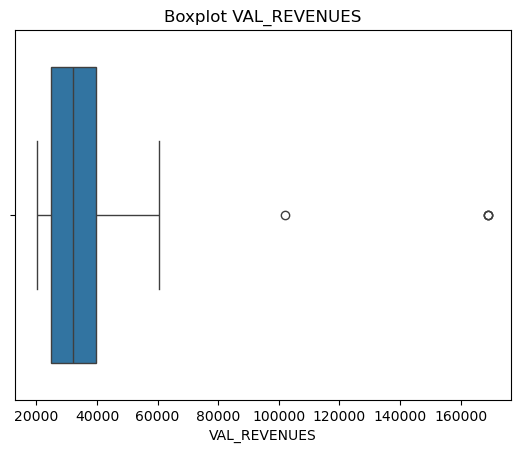

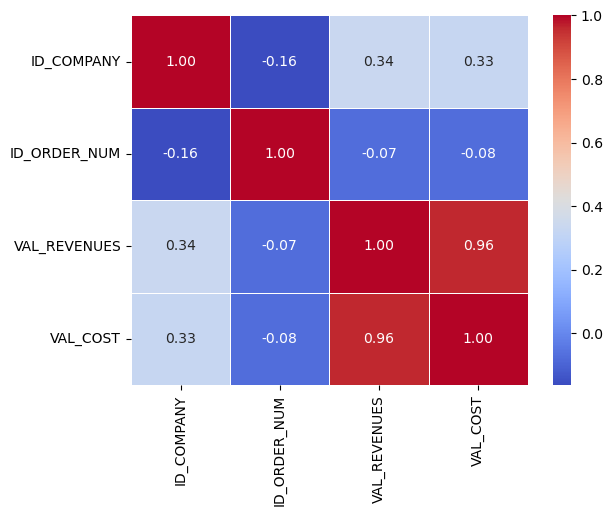

ANALISI VARIABILI CATEGORICHE


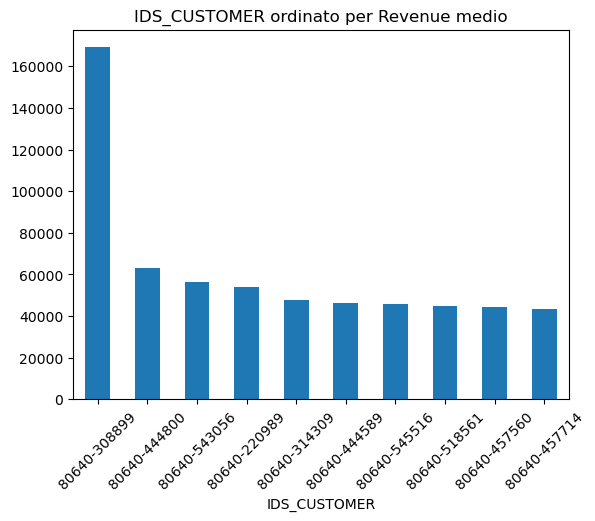

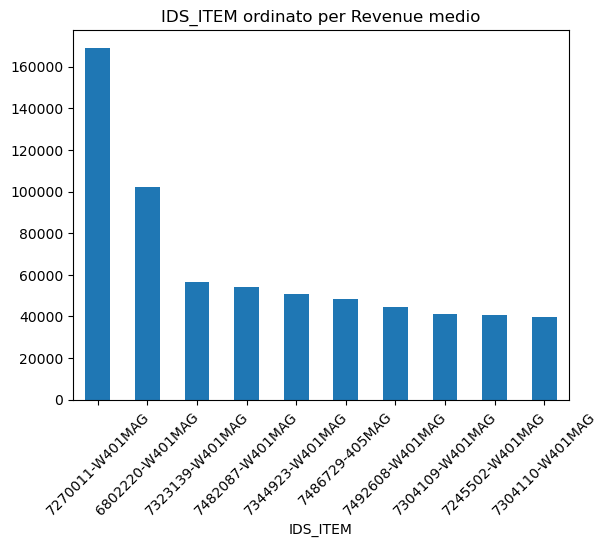

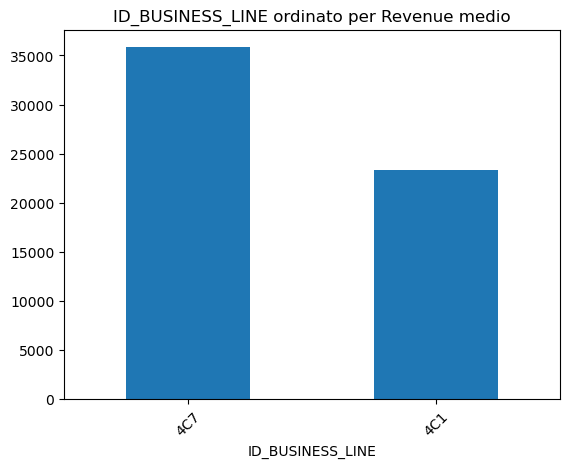

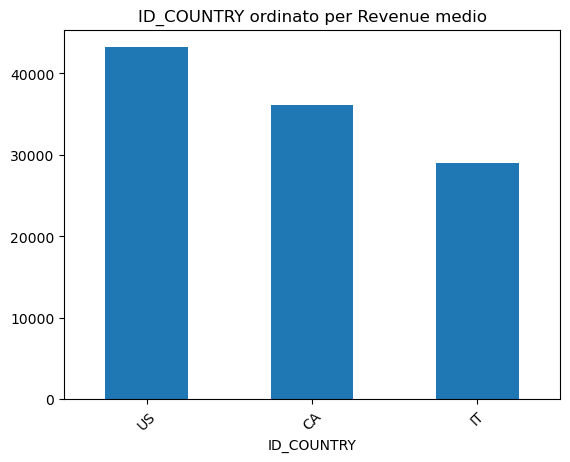

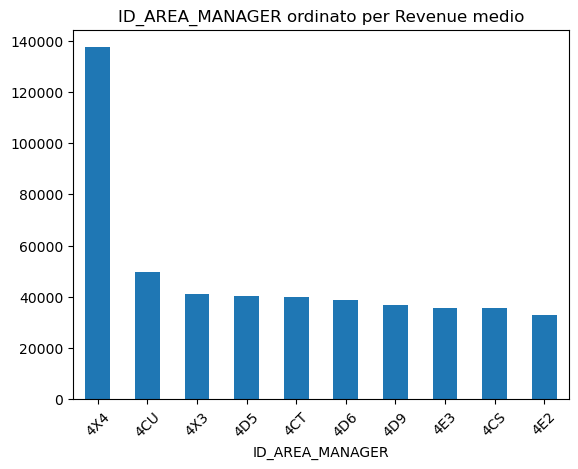

OUTLIER
Numero outlier: 4

Colonna: ID_COMPANY
       Modalità  Freq Ass  Freq Rel (%)  Freq Rel Cum (%)
Indice                                                   
1            40       114          50.9              50.9
2         80640       110          49.1             100.0

Colonna: ID_ORDER_NUM
        Modalità  Freq Ass  Freq Rel (%)  Freq Rel Cum (%)
Indice                                                    
1       25400051         1           0.4               0.4
2       25400072         1           0.4               0.9
3       25400075         1           0.4               1.3
4       25400082         5           2.2               3.6
5       25400089         3           1.3               4.9
...          ...       ...           ...               ...
206     26422305         1           0.4              98.2
207     26423297         1           0.4              98.7
208     26424432         1           0.4              99.1
209     26426728         1           0.4         

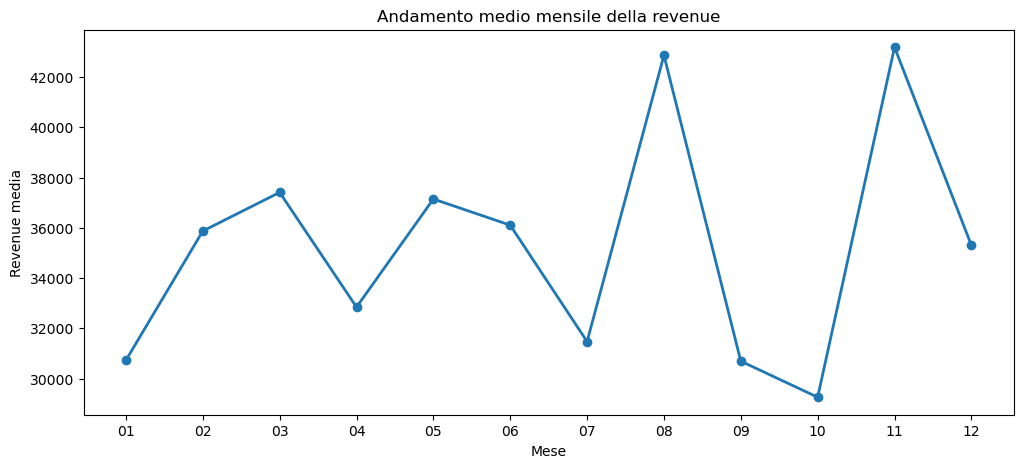

In [87]:
def main():
    
    df = pd.read_csv("SALES_OLAP.csv")
    # CONVERSIONE DATE perchè si legge da .csv
    df["ID_ORDER_DATE"] = pd.to_datetime(df["ID_ORDER_DATE"])
    df["ID_INVOICE_DATE"] = pd.to_datetime(df["ID_INVOICE_DATE"])
    # Analisi
    data_profiling(df, target_col="VAL_REVENUES")
    # Conversione  degli ID numerici in stringa
    df["ID_COMPANY"] = df["ID_COMPANY"].astype(object)
    df["ID_ORDER_NUM"] = df["ID_ORDER_NUM"].astype(object)
    analisi_outlier(df)
    statistiche_dettagliate(df)
    analisi_temporale(df)

    return df

if __name__ == "__main__":
    main()